In [1]:
import kagglehub, os, cv2
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, ifft2, fftshift, ifftshift

In [2]:

path = kagglehub.dataset_download("iamsouravbanerjee/animal-image-dataset-90-different-animals")

print("Path to dataset files:", path)

100%|███████████████████████████████████████████████████████████████████████████████| 656M/656M [00:42<00:00, 16.0MB/s]

Extracting files...


Path to dataset files: C:\Users\asus\.cache\kagglehub\datasets\iamsouravbanerjee\animal-image-dataset-90-different-animals\versions\5


In [4]:
image_files = []
for root, dirs, files in os.walk(path):
    for f in files:
        if f.lower().endswith(('.jpg', '.png', '.jpeg')):
            image_files.append(os.path.join(root, f))

print("Found", len(image_files), "images")


Found 5400 images


In [5]:
def load_image_gray(fname, size=256):
    img = cv2.imread(fname, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (size, size))
    return img.astype(np.float32)/255.0

images = [load_image_gray(f) for f in image_files[:10]]  # take first 5 for demo

In [6]:
def motion_blur_psf(length, angle_deg, size):
    psf = np.zeros((size,size))
    angle = np.deg2rad(angle_deg)
    cx, cy = size//2, size//2
    dx, dy = np.cos(angle), np.sin(angle)
    for i in range(length):
        x = int(round(cx + (i - length//2) * dx))
        y = int(round(cy + (i - length//2) * dy))
        if 0 <= x < size and 0 <= y < size:
            psf[y,x] = 1
    psf /= psf.sum()
    return psf

In [7]:
def degrade_image(img, psf, noise_sigma=0.01):
    H = fft2(ifftshift(psf))
    G = fft2(img) * H
    g = np.real(ifft2(G))
    g_noisy = g + np.random.normal(0, noise_sigma, img.shape)
    return np.clip(g_noisy,0,1), H

In [8]:
def inverse_filter(G, H, eps=1e-3):
    H_mod = H.copy()
    H_mod[np.abs(H_mod) < eps] = eps
    F_hat = G / H_mod
    return np.real(ifft2(F_hat))

def wiener_filter(G, H, K):
    H_conj = np.conj(H)
    denom = (np.abs(H)**2 + K)
    F_hat = (H_conj / denom) * G
    return np.real(ifft2(F_hat))

In [9]:
psf = motion_blur_psf(length=15, angle_deg=0, size=256)
noise_sigma = 0.02

for idx, img in enumerate(images):
    degraded, H = degrade_image(img, psf, noise_sigma=noise_sigma)
    G = fft2(degraded)

    signal_var = np.var(img)
    noise_var = noise_sigma**2
    K = noise_var / (signal_var + 1e-12)

    inv_res = inverse_filter(G, H, eps=1e-2)
    wiener_res = wiener_filter(G, H, K)

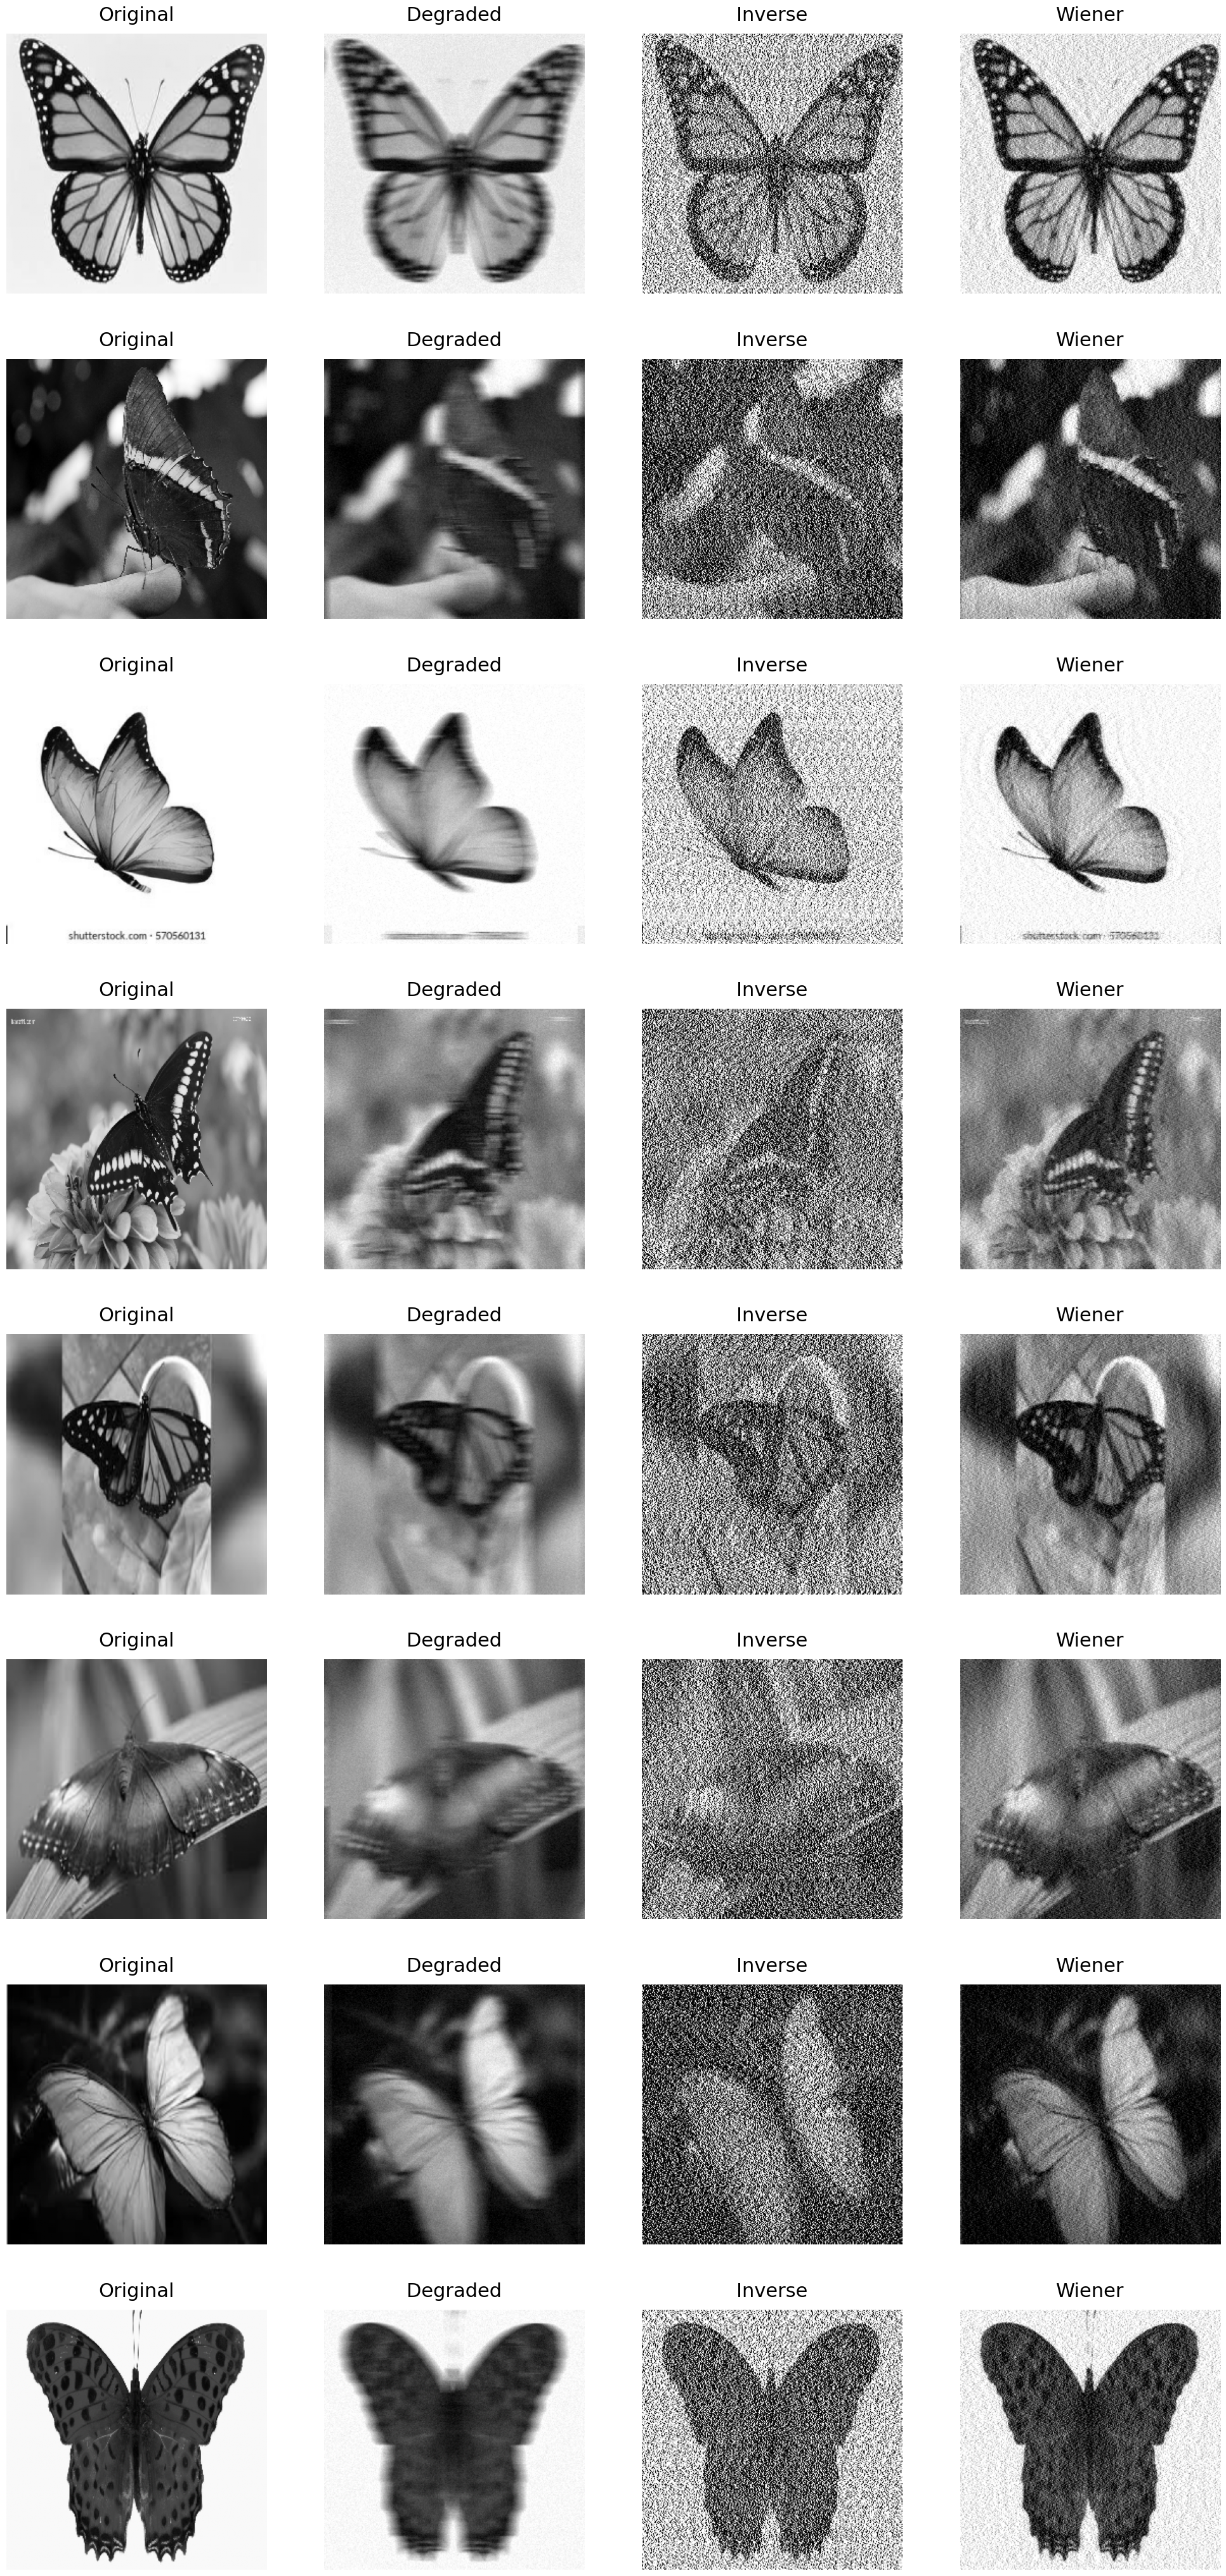

In [13]:
images = [load_image_gray(f) for f in image_files[500:508]]

rows, cols = len(images), 4
fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*5))

for idx, img in enumerate(images):
    degraded, H = degrade_image(img, psf, noise_sigma=noise_sigma)
    G = fft2(degraded)

    signal_var = np.var(img)
    noise_var = noise_sigma**2
    K = noise_var / (signal_var + 1e-12)

    inv_res = inverse_filter(G, H, eps=1e-2)
    wiener_res = wiener_filter(G, H, K)

    results = [img, degraded, np.clip(inv_res,0,1), np.clip(wiener_res,0,1)]
    titles  = ["Original", "Degraded", "Inverse", "Wiener"]

    for j in range(cols):
        ax = axes[idx, j] if rows > 1 else axes[j]
        ax.imshow(results[j], cmap="gray")
        ax.set_title(titles[j], fontsize=22, pad=15)  # big clear titles
        ax.axis("off")

plt.subplots_adjust(left=0, right=1, top=1, bottom=0,
                    wspace=0.01, hspace=0.25)

plt.show()
